# The total energy and the band structure of silicon

The ground state of a crystal: the density that reproduces itself, and the
eigenvalues of the potential it makes. What is minimised is the Kohn-Sham total
energy as a functional of the density,

$$E[n] = T_s[n] + \int v_{\rm ext}(\mathbf r)\, n(\mathbf r)\, d\mathbf r
        + E_{\rm H}[n] + E_{\rm xc}[n] + E_{\rm ion-ion},$$

and self-consistency is the statement that the density built from the eigenstates
of the potential $v[n]$ is the same $n$ that produced it.

On `test-suite/pw_scf/scf.in`, two atoms of fcc silicon in LDA:

| | pypresso | `pw.x` |
|---|---|---|
| total energy | **-15.79449557 Ry** | -15.79449557 Ry |
| every term of it | | agrees to **1e-9 Ry** |
| eigenvalues along the path | | agree to **0.00025 eV** |
| indirect gap | **0.4885 eV** | experiment: 1.17 eV |

That last row is the band gap problem, in one number, and it is a property of
LDA rather than of this code: notebook 24 is about a functional that fixes it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table, read_qe_output
from pypresso.units import RY_TO_EV

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_scf")
PSEUDO = Path("../tests/data/pseudo")

silicon = Calculator.from_file(QE / "scf.in", pseudo_dir=PSEUDO, conv_thr=1e-10)
scf = silicon.get_scf()

print(f"total energy   {scf.total_energy:.8f} Ry   in {scf.iterations} iterations")

total energy   -15.79449557 Ry   in 7 iterations


That one call is the whole of density functional theory in practice: build the
potential from the density, diagonalise at every k-point, build a new density
from the occupied states and symmetrise it, mix it into the old one, repeat
until the two agree.

Two of those steps are easy to leave out and neither fails loudly.
**Symmetrisation:** two k-points stand in for the whole Brillouin zone only
because of symmetry, and a density built from them alone does not have the
crystal's, so the total comes out wrong in the third decimal with degeneracies
split by tens of meV. **Mixing:** feeding the output density straight back in
diverges, charge sloshing from one side of the cell to the other and amplified
each time by the Hartree term. Notebook 17 is about what to do when it still
will not converge.

## The energy term by term

Comparing only the total is too forgiving. The total energy is variational, so
it is second order in the error of the density: it can look right while a term
inside it is wrong, the errors cancelling. The decomposition localises a
disagreement to one piece of physics.

In [2]:
# A re-run of pw.x on this input rather than the shipped reference, which dates
# from QE 6.0 and stops at conv_thr = 1e-6, well above the level compared here.
qe = read_qe_output(Path("../tests/data/qe/reference.out.pw_scf-scf"))

rows = [(term, value, qe.energy_terms[term])
        for term, value in scf.energy_terms.items()]
rows.append(("TOTAL", scf.total_energy, qe.total_energy))
print(comparison_table(rows, fmt="{:.8f}",
                       headers=("term [Ry]", "pypresso", "pw.x", "difference")))

term [Ry]         pypresso          pw.x  difference
one-electron    4.83371975    4.83371826     1.5e-06
hartree         1.08439441    1.08439697     2.6e-06
xc             -4.81285115   -4.81285222     1.1e-06
ewald         -16.89975858  -16.89975858     2.8e-09
TOTAL         -15.79449557  -15.79449557     8.7e-10


## The bands

With the density converged the potential is frozen and the Hamiltonian is
diagonalised along a path through the Brillouin zone. Nothing about that step is
self-consistent, which is why it can use k-points that would make no sense as an
integration grid.

The path is the one `scf-1.in` asks for, and that input runs after `scf.in`
sharing its output directory, so the reference eigenvalues belong to precisely
the density converged above.

largest disagreement   0.00025 eV
indirect gap           0.4885 eV


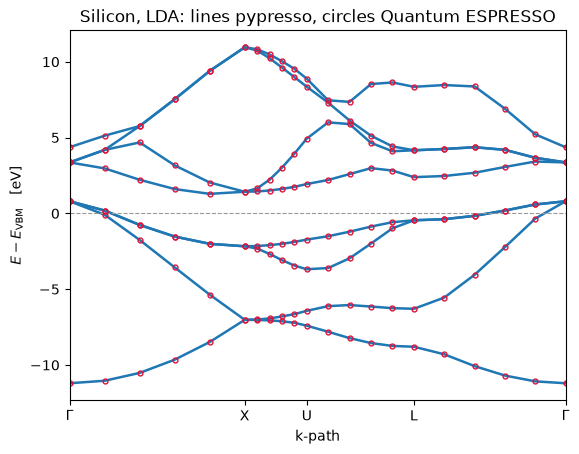

In [3]:
path = Calculator.from_file(QE / "scf-1.in", pseudo_dir=PSEUDO).system.kpoints
bands = silicon.get_bands(kpoints=path, nbnd=8)
theirs = read_qe_output(QE / "benchmark.out.git.inp=scf-1.in").eigenvalues[0]

ax = bands.plot(color="C0", lw=1.8)
ax.plot(bands.path_length, theirs - bands.homo * RY_TO_EV,
        "o", color="crimson", ms=3.5, mfc="none", lw=0)
ax.set_xticks(bands.path_length[::5])
ax.set_xticklabels([r"$\Gamma$", "X", "U", "L", r"$\Gamma$"])
ax.set_ylabel(r"$E - E_{\rm VBM}$   [eV]")
ax.set_title("Silicon, LDA: lines pypresso, circles Quantum ESPRESSO")

print("largest disagreement   %.5f eV" % np.abs(bands.eigenvalues_ev - theirs).max())
print("indirect gap           %.4f eV" % bands.gap(8))

The curves and the circles lie on top of each other to 0.2 meV. The threefold
degeneracies at $\Gamma$ are exact rather than approximate, which is the visible
payoff of symmetrising the density, and the gap is indirect: it runs from
$\Gamma$ to a point most of the way out to X, not to a high-symmetry point at
all.

## Where the electrons went

The physical content of the run is in the density, and the way to see it is a
plane cut through the bond. Charge is piled up between the two atoms, which is
the covalent bond of diamond silicon and is what distinguishes it from a
free-electron metal.

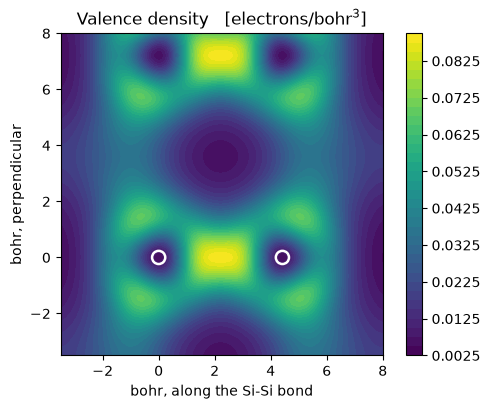

In [4]:
from pypresso.basis.builder import build_basis        # no facade route to rho(G)
from pypresso.basis.fft import r_to_g

system = silicon.system
basis = build_basis(system)
rho_g = np.asarray(r_to_g(scf.total_density, basis.dense.fft_index))
g = np.asarray(basis.dense.cartesian(system.cell))
tau = np.asarray(system.structure.positions)

along = (tau[1] - tau[0]) / np.linalg.norm(tau[1] - tau[0])
across = np.cross(along, [0.0, 0.0, 1.0])
across /= np.linalg.norm(across)
span = np.linspace(-3.5, 8.0, 200)
u, v = np.meshgrid(span, span, indexing="ij")
plane = (tau[0] + u[..., None] * along + v[..., None] * across).reshape(-1, 3)
image = (np.exp(1j * plane @ g.T) * rho_g).sum(axis=1).real.reshape(u.shape)

fig, ax = plt.subplots(figsize=(5.4, 4.2))
mesh = ax.contourf(span, span, image.T, levels=40, cmap="viridis")
ax.scatter([0.0, np.linalg.norm(tau[1] - tau[0])], [0.0, 0.0], s=90,
           facecolors="none", edgecolors="white", lw=1.8)
ax.set_aspect("equal")
ax.set_xlabel("bohr, along the Si-Si bond")
ax.set_ylabel("bohr, perpendicular")
ax.set_title(r"Valence density   [electrons/bohr$^3$]")
fig.colorbar(mesh, ax=ax)
fig.tight_layout()

## What it refuses

`K_POINTS gamma` selects the half-sphere storage of the gamma-point trick. That
storage is built but not consumed, so such a run is substituted by an explicit
$k = 0$ on the full sphere, which is the same physics at twice the cost, and it
says so rather than doing it quietly. A functional the pseudopotentials name and
this code does not implement is refused rather than replaced by LDA.

---
The tests behind this notebook: `tests/regression/test_scf.py`,
`tests/unit/test_qeref.py`.